# Практическая работа 8: Разделительная кластеризация | Hepta и Target

Цель исследования состоит в анализе поведения алгоритмов `k-Means` и `k-Medoids`
на выпуклом и невыпуклом эталонных наборах данных, а также в изучении их чувствительности
к локальным шумовым искажениям.


## 1. Импорты и конфигурация


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from kmedoids import KMedoids

RANDOM_STATE = 42
NOISE_SCALE_RANGE = (2.0, 4.0)
NOISE_FRACTIONS = (0.01, 0.03, 0.05, 0.10)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 11
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

NOTEBOOK_DIR = Path.cwd()
HEPTA_PATH = NOTEBOOK_DIR / "hepta.csv"
TARGET_PATH = NOTEBOOK_DIR / "target.csv"

HEPTA_PATH, TARGET_PATH


(PosixPath('/Users/mikhail/Developer/SUSU.PE/СП-М-О-ИАД-2025/Практика/Практика 8 - Разделительная кластеризация/hepta.csv'),
 PosixPath('/Users/mikhail/Developer/SUSU.PE/СП-М-О-ИАД-2025/Практика/Практика 8 - Разделительная кластеризация/target.csv'))

## 2. Описание данных

В работе используются два benchmark-набора из семейства FCPS.

**Набор `Hepta`:**
- трехмерный набор данных;
- содержит `212` наблюдений;
- характеризуется `7` естественными выпуклыми кластерами;
- используется для исследования стандартной разделительной кластеризации и устойчивости к шуму.

**Набор `Target`:**
- двумерный набор данных;
- содержит `770` наблюдений;
- используется как невыпуклая структура для демонстрации ограничений разделительных алгоритмов.

В рамках шумового эксперимента из набора `Hepta` формируются четыре искаженные модификации
с долями зашумления `1%`, `3%`, `5%` и `10%`.


## 3. Загрузка датасетов


In [2]:
def load_dataset(path: Path) -> pd.DataFrame:
    """Загружает CSV-файл с benchmark-набором данных.

    Parameters
    ----------
    path : Path
        Путь к CSV-файлу с данными.

    Returns
    -------
    pd.DataFrame
        Таблица наблюдений в исходной структуре CSV-файла.
    """
    return pd.read_csv(path)


In [3]:
hepta_df = load_dataset(HEPTA_PATH)
target_df = load_dataset(TARGET_PATH)


In [4]:
pd.DataFrame(
    [
        {
            "dataset": "Hepta",
            "n_objects": len(hepta_df),
            "n_features": len([column for column in hepta_df.columns if column.startswith("x")]),
            "n_reference_clusters": hepta_df["true_cluster"].nunique(),
        },
        {
            "dataset": "Target",
            "n_objects": len(target_df),
            "n_features": len([column for column in target_df.columns if column.startswith("x")]),
            "n_reference_clusters": target_df["true_cluster"].nunique(),
        },
    ]
)


,dataset,n_objects,n_features,n_reference_clusters
0,Hepta,212,3,7
1,Target,770,2,6


In [5]:
hepta_df.head()


,object_id,x1,x2,x3,true_cluster
0,1,-0.0633,0.0277,0.0227,1
1,2,-0.0007,0.0482,0.0692,1
2,3,-0.0608,-0.0091,0.0531,1
3,4,0.0133,-0.0119,0.0553,1
4,5,-0.0545,-0.0038,0.0017,1


In [6]:
target_df.head()


,object_id,x1,x2,true_cluster
0,1,-3.0000,-3.0000,5
1,2,-3.0000,3.0000,4
2,3,3.0000,-3.0000,6
3,4,3.0000,3.0000,3
4,5,-0.4171,0.1148,1


In [7]:
hepta_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   object_id     212 non-null    int64  
 1   x1            212 non-null    float64
 2   x2            212 non-null    float64
 3   x3            212 non-null    float64
 4   true_cluster  212 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 8.4 KB


In [8]:
target_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   object_id     770 non-null    int64  
 1   x1            770 non-null    float64
 2   x2            770 non-null    float64
 3   true_cluster  770 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 24.2 KB


## 4. Подготовка данных и вспомогательные функции


In [9]:
def standardize_features(
    data: pd.DataFrame,
    feature_columns: list[str],
    fitted_scaler: StandardScaler | None = None,
) -> tuple[pd.DataFrame, StandardScaler]:
    """Стандартизует признаки набора данных.

    Parameters
    ----------
    data : pd.DataFrame
        Исходная таблица наблюдений.
    feature_columns : list[str]
        Список стандартизируемых признаков.
    fitted_scaler : StandardScaler | None, default=None
        Уже обученный scaler. Если не задан, scaler обучается на текущем наборе.

    Returns
    -------
    tuple[pd.DataFrame, StandardScaler]
        Стандартизованная таблица и использованный объект scaler.
    """
    scaler = fitted_scaler or StandardScaler()
    transformed = data.copy()
    if fitted_scaler is None:
        transformed[feature_columns] = scaler.fit_transform(transformed[feature_columns])
    else:
        transformed[feature_columns] = scaler.transform(transformed[feature_columns])
    return transformed, scaler


In [10]:
def add_sparse_outlier_noise(
    data: pd.DataFrame,
    feature_columns: list[str],
    fraction: float,
    random_state: int,
    scale_range: tuple[float, float] = NOISE_SCALE_RANGE,
) -> tuple[pd.DataFrame, np.ndarray]:
    """Вносит локальные выбросы в случайно выбранную долю наблюдений.

    Parameters
    ----------
    data : pd.DataFrame
        Исходный набор данных.
    feature_columns : list[str]
        Признаки, по которым допускается искажение.
    fraction : float
        Доля искажаемых объектов.
    random_state : int
        Значение генератора случайных чисел.
    scale_range : tuple[float, float], default=NOISE_SCALE_RANGE
        Интервал амплитуд шума в единицах стандартного отклонения.

    Returns
    -------
    tuple[pd.DataFrame, np.ndarray]
        Зашумленный набор данных и индексы искаженных объектов.
    """
    rng = np.random.default_rng(random_state)
    noisy = data.copy()
    feature_stds = noisy[feature_columns].std(axis=0, ddof=0).to_numpy()
    n_noisy = max(1, int(round(len(noisy) * fraction)))
    noisy_indices = np.sort(rng.choice(len(noisy), size=n_noisy, replace=False))

    for row_index in noisy_indices:
        n_dimensions = int(rng.integers(1, len(feature_columns) + 1))
        selected_positions = rng.choice(len(feature_columns), size=n_dimensions, replace=False)
        magnitudes = rng.uniform(scale_range[0], scale_range[1], size=n_dimensions) * feature_stds[selected_positions]
        signs = rng.choice([-1.0, 1.0], size=n_dimensions)

        for position, delta in zip(selected_positions, signs * magnitudes):
            column = feature_columns[position]
            noisy.loc[row_index, column] += float(delta)

    return noisy, noisy_indices


In [11]:
def run_kmeans_grid(
    data: pd.DataFrame,
    feature_columns: list[str],
    k_values: range,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """Запускает серию экспериментов алгоритма k-Means по набору значений `k`.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных.
    feature_columns : list[str]
        Числовые признаки для кластеризации.
    k_values : range
        Последовательность значений числа кластеров.
    random_state : int, default=RANDOM_STATE
        Инициализация генератора случайных чисел.

    Returns
    -------
    pd.DataFrame
        Таблица с метками кластеров, инерцией и коэффициентом силуэта.
    """
    X = data[feature_columns].to_numpy()
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        labels = model.fit_predict(X)
        silhouette = silhouette_score(X, labels) if len(set(labels)) > 1 else np.nan
        rows.append(
            {
                "k": k,
                "labels": labels,
                "inertia": float(model.inertia_),
                "silhouette": float(silhouette),
            }
        )
    return pd.DataFrame(rows)


In [12]:
def run_kmedoids_grid(
    data: pd.DataFrame,
    feature_columns: list[str],
    k_values: range,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    """Запускает серию экспериментов алгоритма k-Medoids по набору значений `k`.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных.
    feature_columns : list[str]
        Числовые признаки для кластеризации.
    k_values : range
        Последовательность значений числа кластеров.
    random_state : int, default=RANDOM_STATE
        Инициализация генератора случайных чисел.

    Returns
    -------
    pd.DataFrame
        Таблица с метками кластеров и коэффициентом силуэта.
    """
    X = data[feature_columns].to_numpy()
    rows = []
    for k in k_values:
        model = KMedoids(
            n_clusters=k,
            metric="euclidean",
            method="fasterpam",
            random_state=random_state,
        )
        labels = model.fit_predict(X)
        silhouette = silhouette_score(X, labels) if len(set(labels)) > 1 else np.nan
        rows.append(
            {
                "k": k,
                "labels": labels,
                "silhouette": float(silhouette),
            }
        )
    return pd.DataFrame(rows)


In [13]:
def plot_metric_curves(
    results: pd.DataFrame,
    x_column: str,
    metric_columns: list[str],
    figure_title: str,
) -> None:
    """Строит кривые метрик качества от управляющего параметра.

    Parameters
    ----------
    results : pd.DataFrame
        Таблица результатов эксперимента.
    x_column : str
        Столбец, откладываемый по оси абсцисс.
    metric_columns : list[str]
        Метрики, визуализируемые на отдельных осях.
    figure_title : str
        Общий заголовок панели графиков.
    """
    figure, axes = plt.subplots(1, len(metric_columns), figsize=(6.0 * len(metric_columns), 4.5))
    if len(metric_columns) == 1:
        axes = [axes]

    for axis, metric_column in zip(axes, metric_columns):
        axis.plot(results[x_column], results[metric_column], marker="o", linewidth=2)
        axis.set_xlabel(x_column)
        axis.set_ylabel(metric_column)
        axis.set_title(f"{metric_column} от {x_column}")

    figure.suptitle(figure_title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


In [14]:
def plot_cluster_grid(
    data: pd.DataFrame,
    feature_columns: list[str],
    label_pairs: list[tuple[str, np.ndarray]],
    figure_title: str,
    n_columns: int = 4,
) -> None:
    """Строит панель точечных диаграмм для нескольких кластерных разбиений.

    Parameters
    ----------
    data : pd.DataFrame
        Набор данных для визуализации.
    feature_columns : list[str]
        Используемые признаки.
    label_pairs : list[tuple[str, np.ndarray]]
        Пары вида `(заголовок, метки кластеров)`.
    figure_title : str
        Общий заголовок панели.
    n_columns : int, default=4
        Число столбцов в панели.
    """
    n_panels = len(label_pairs)
    n_rows = int(np.ceil(n_panels / n_columns))
    is_3d = len(feature_columns) == 3
    figure = plt.figure(figsize=(4.6 * n_columns, 4.2 * n_rows))
    palette = sns.color_palette("tab10", n_colors=12)

    for index, (title, labels) in enumerate(label_pairs, start=1):
        if is_3d:
            axis = figure.add_subplot(n_rows, n_columns, index, projection="3d")
        else:
            axis = figure.add_subplot(n_rows, n_columns, index)

        colors = []
        for label in labels:
            if label == -1:
                colors.append((0.15, 0.15, 0.15))
            else:
                colors.append(palette[int(label) % len(palette)])

        if is_3d:
            axis.scatter(
                data[feature_columns[0]],
                data[feature_columns[1]],
                data[feature_columns[2]],
                c=colors,
                s=18,
                alpha=0.85,
            )
            axis.set_xlabel(feature_columns[0])
            axis.set_ylabel(feature_columns[1])
            axis.set_zlabel(feature_columns[2])
        else:
            axis.scatter(
                data[feature_columns[0]],
                data[feature_columns[1]],
                c=colors,
                s=18,
                alpha=0.85,
            )
            axis.set_xlabel(feature_columns[0])
            axis.set_ylabel(feature_columns[1])

        axis.set_title(title)

    figure.suptitle(figure_title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


### 4.1. Стандартизация выпуклого набора `Hepta`


In [15]:
hepta_scaled_df, hepta_scaler = standardize_features(hepta_df, ["x1", "x2", "x3"])
target_scaled_df, _ = standardize_features(target_df, ["x1", "x2"])


### 4.2. Формирование зашумленных модификаций набора `Hepta`


In [16]:
hepta_noisy_scaled = {}

for index, fraction in enumerate(NOISE_FRACTIONS, start=1):
    noisy_raw, noisy_indices = add_sparse_outlier_noise(
        data=hepta_df,
        feature_columns=["x1", "x2", "x3"],
        fraction=fraction,
        random_state=RANDOM_STATE + index,
    )
    noisy_scaled, _ = standardize_features(
        data=noisy_raw,
        feature_columns=["x1", "x2", "x3"],
        fitted_scaler=hepta_scaler,
    )
    hepta_noisy_scaled[fraction] = noisy_scaled.assign(is_noisy=noisy_scaled.index.isin(noisy_indices))


In [17]:
pd.DataFrame(
    [
        {
            "noise_fraction": fraction,
            "n_noisy_objects": int(dataset["is_noisy"].sum()),
        }
        for fraction, dataset in hepta_noisy_scaled.items()
    ]
)


,noise_fraction,n_noisy_objects
0,0.0100,2
1,0.0300,6
2,0.0500,11
3,0.1000,21


## 5. Эксперименты

### 5.1. Разделительная кластеризация выпуклого набора `Hepta`


In [18]:
hepta_kmeans_results = run_kmeans_grid(hepta_scaled_df, ["x1", "x2", "x3"], range(3, 10))
hepta_kmeans_results[["k", "inertia", "silhouette"]]


,k,inertia,silhouette
0,3,355.7989,0.3572
1,4,258.8001,0.4553
2,5,167.3131,0.5504
3,6,87.3532,0.6495
4,7,39.1748,0.7021
5,8,36.4456,0.6600
6,9,33.7981,0.6164


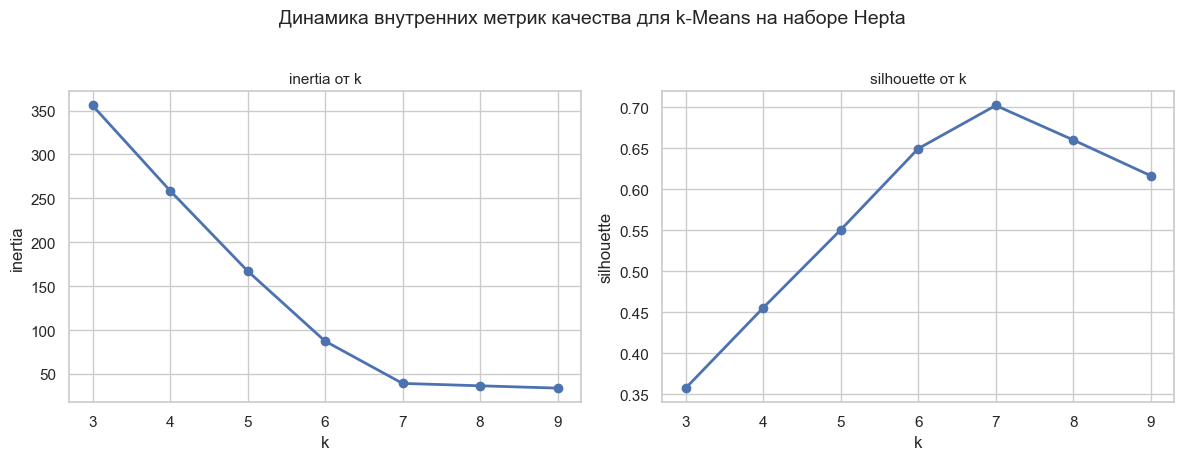

In [19]:
plot_metric_curves(
    results=hepta_kmeans_results,
    x_column="k",
    metric_columns=["inertia", "silhouette"],
    figure_title="Динамика внутренних метрик качества для k-Means на наборе Hepta",
)


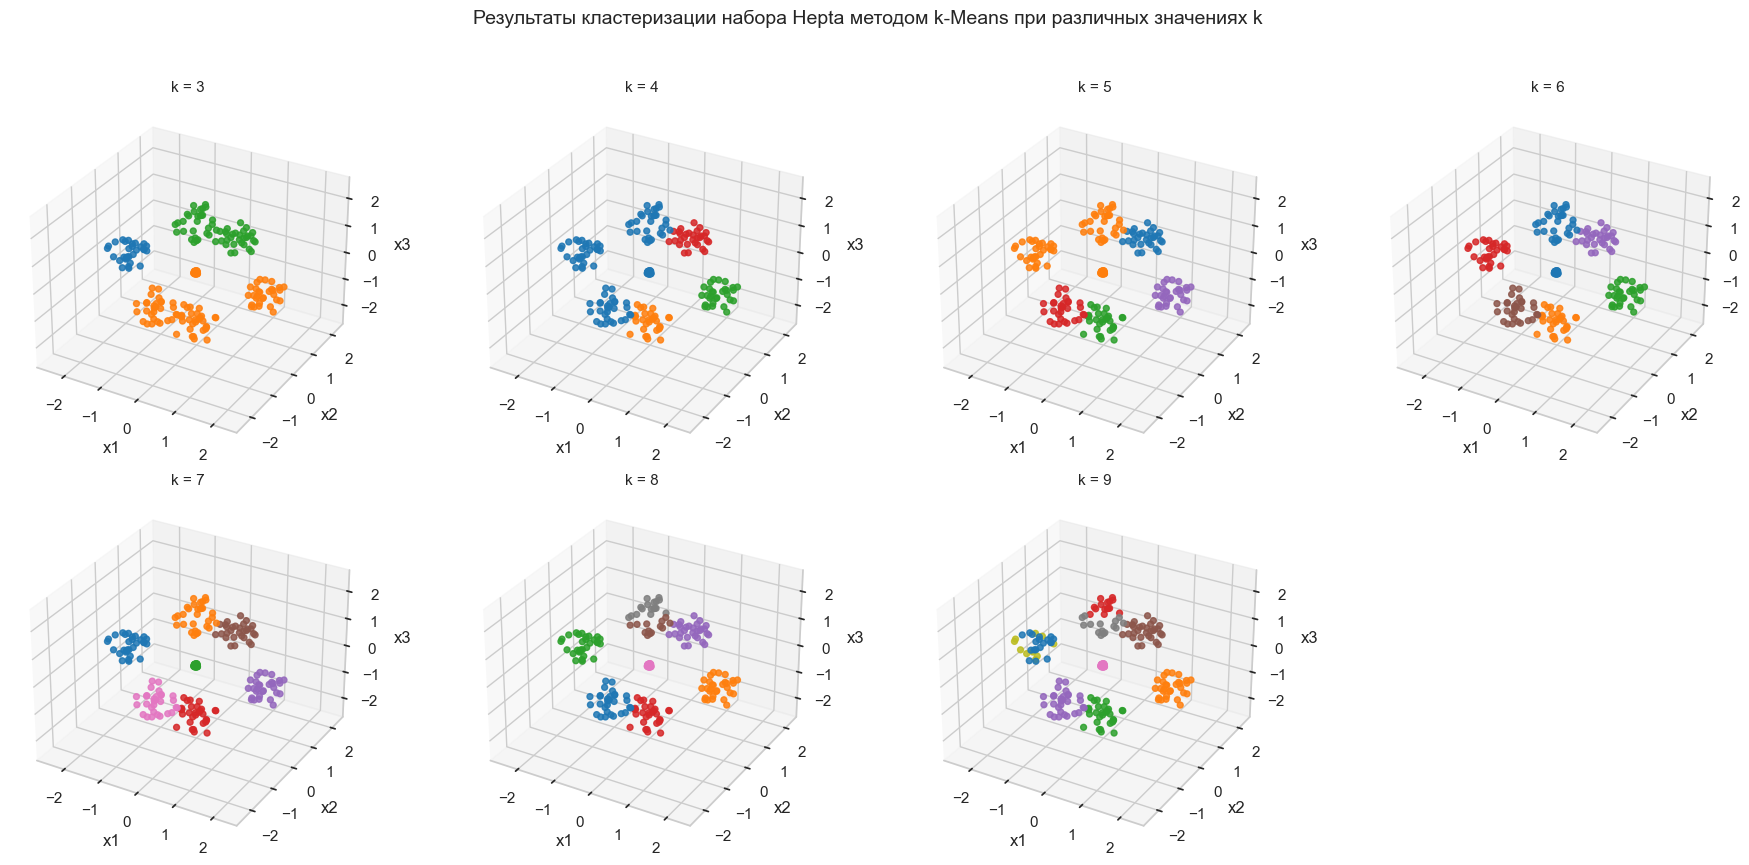

In [20]:
plot_cluster_grid(
    data=hepta_scaled_df,
    feature_columns=["x1", "x2", "x3"],
    label_pairs=[(f"k = {row.k}", row.labels) for row in hepta_kmeans_results.itertuples()],
    figure_title="Результаты кластеризации набора Hepta методом k-Means при различных значениях k",
)


### 5.2. Анализ устойчивости `k-Means` и `k-Medoids` к шуму


In [21]:
hepta_noisy_kmeans_results = {
    fraction: run_kmeans_grid(dataset, ["x1", "x2", "x3"], range(3, 10))
    for fraction, dataset in hepta_noisy_scaled.items()
}

hepta_noisy_kmedoids_results = {
    fraction: run_kmedoids_grid(dataset, ["x1", "x2", "x3"], range(3, 10))
    for fraction, dataset in hepta_noisy_scaled.items()
}


In [22]:
pd.concat(
    [
        hepta_noisy_kmeans_results[fraction][["k", "inertia", "silhouette"]].assign(
            noise_fraction=fraction,
            algorithm="k-Means",
        )
        for fraction in NOISE_FRACTIONS
    ],
    ignore_index=True,
)


,k,inertia,silhouette,noise_fraction,algorithm
0,3,375.6771,0.3541,0.0100,k-Means
1,4,276.2983,0.4480,0.0100,k-Means
2,5,184.4140,0.5446,0.0100,k-Means
3,6,104.6668,0.6406,0.0100,k-Means
4,7,56.4884,0.6895,0.0100,k-Means
5,8,39.1616,0.6986,0.0100,k-Means
6,9,36.4117,0.6568,0.0100,k-Means
7,3,447.4207,0.3485,0.0300,k-Means
8,4,339.1782,0.4412,0.0300,k-Means
9,5,248.1847,0.5195,0.0300,k-Means


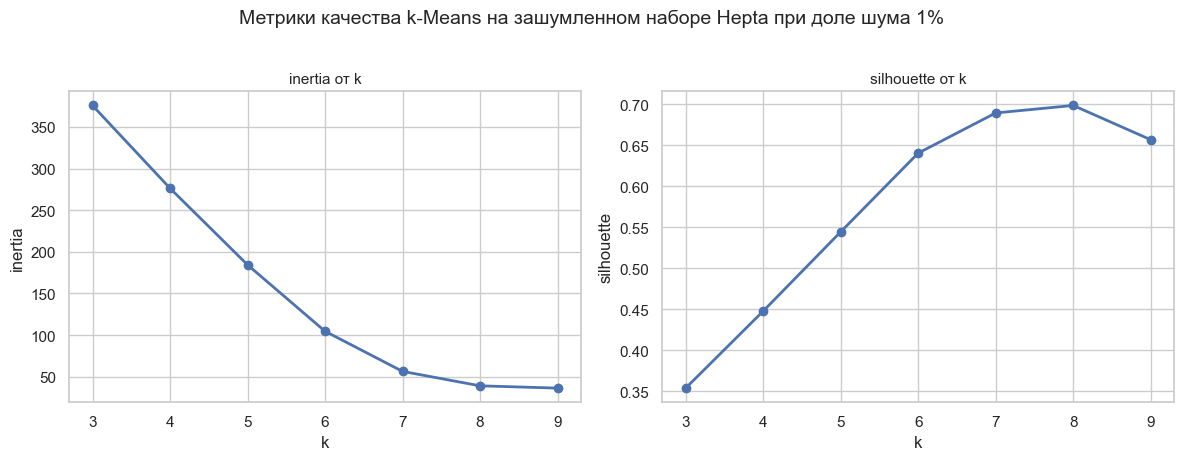

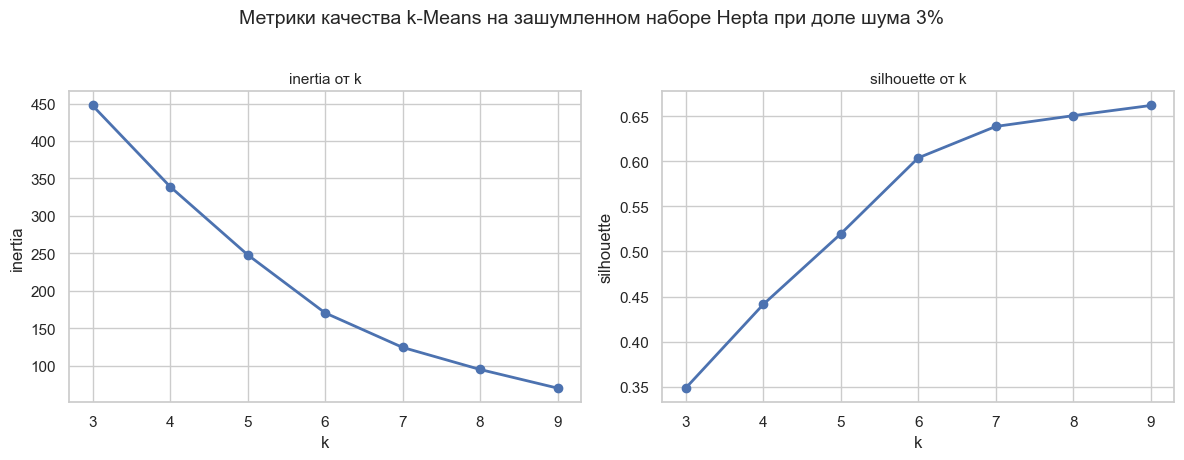

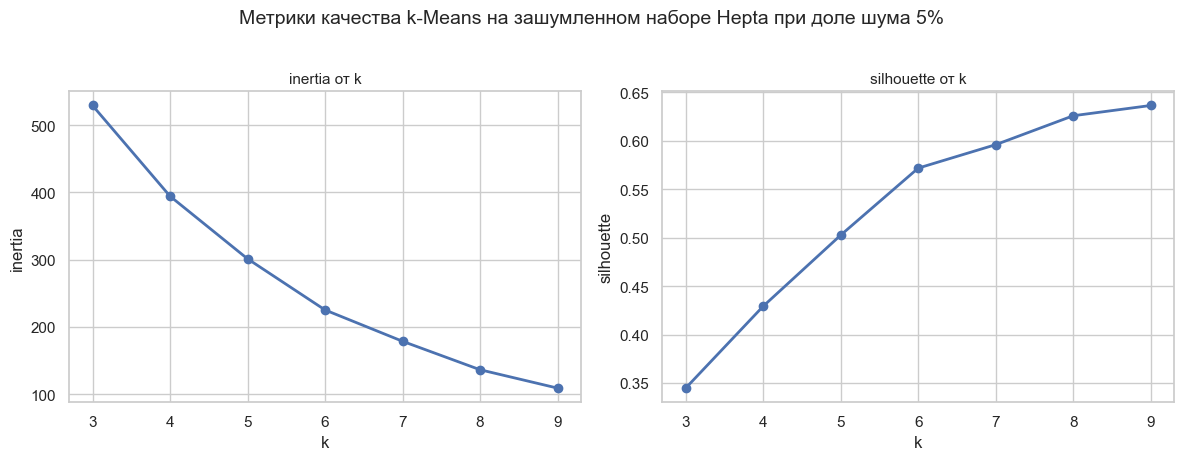

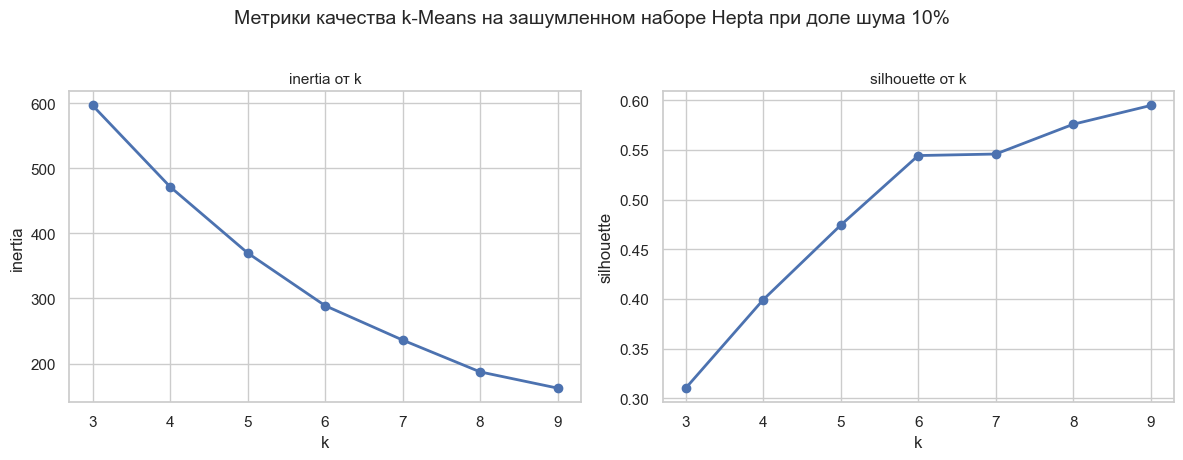

In [23]:
for fraction in NOISE_FRACTIONS:
    plot_metric_curves(
        results=hepta_noisy_kmeans_results[fraction],
        x_column="k",
        metric_columns=["inertia", "silhouette"],
        figure_title=f"Метрики качества k-Means на зашумленном наборе Hepta при доле шума {fraction:.0%}",
    )


In [24]:
pd.concat(
    [
        hepta_noisy_kmedoids_results[fraction][["k", "silhouette"]].assign(
            noise_fraction=fraction,
            algorithm="k-Medoids",
        )
        for fraction in NOISE_FRACTIONS
    ],
    ignore_index=True,
)


,k,silhouette,noise_fraction,algorithm
0,3,0.3355,0.0100,k-Medoids
1,4,0.4414,0.0100,k-Medoids
2,5,0.5467,0.0100,k-Medoids
3,6,0.6406,0.0100,k-Medoids
4,7,0.6895,0.0100,k-Medoids
5,8,0.6986,0.0100,k-Medoids
6,9,0.6572,0.0100,k-Medoids
7,3,0.3481,0.0300,k-Medoids
8,4,0.4409,0.0300,k-Medoids
9,5,0.5193,0.0300,k-Medoids


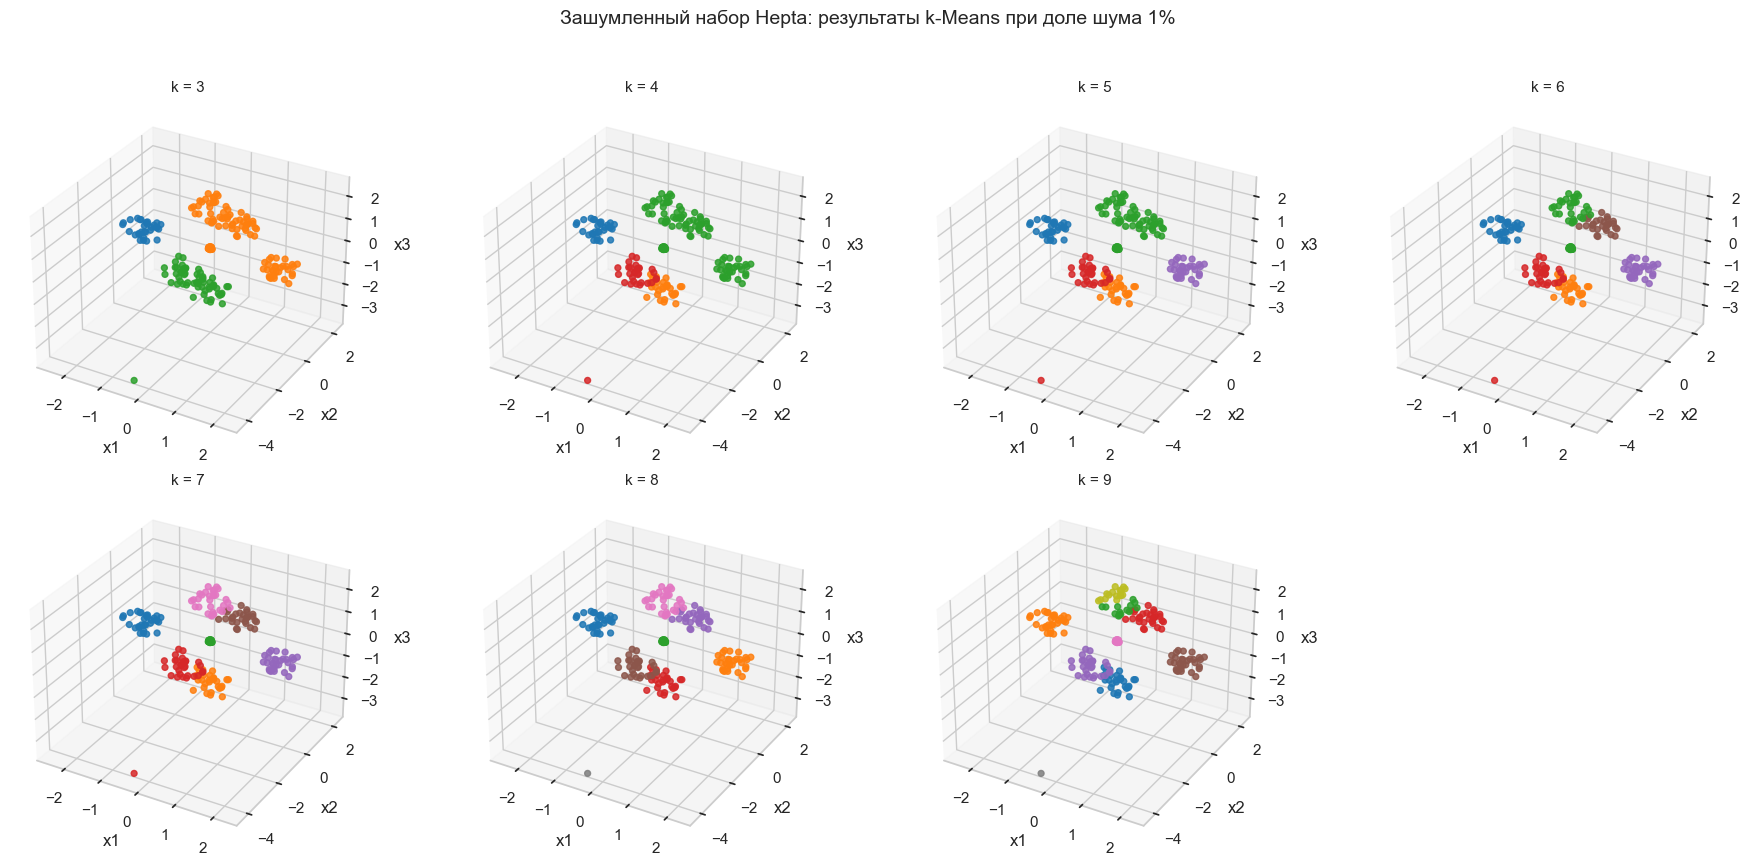

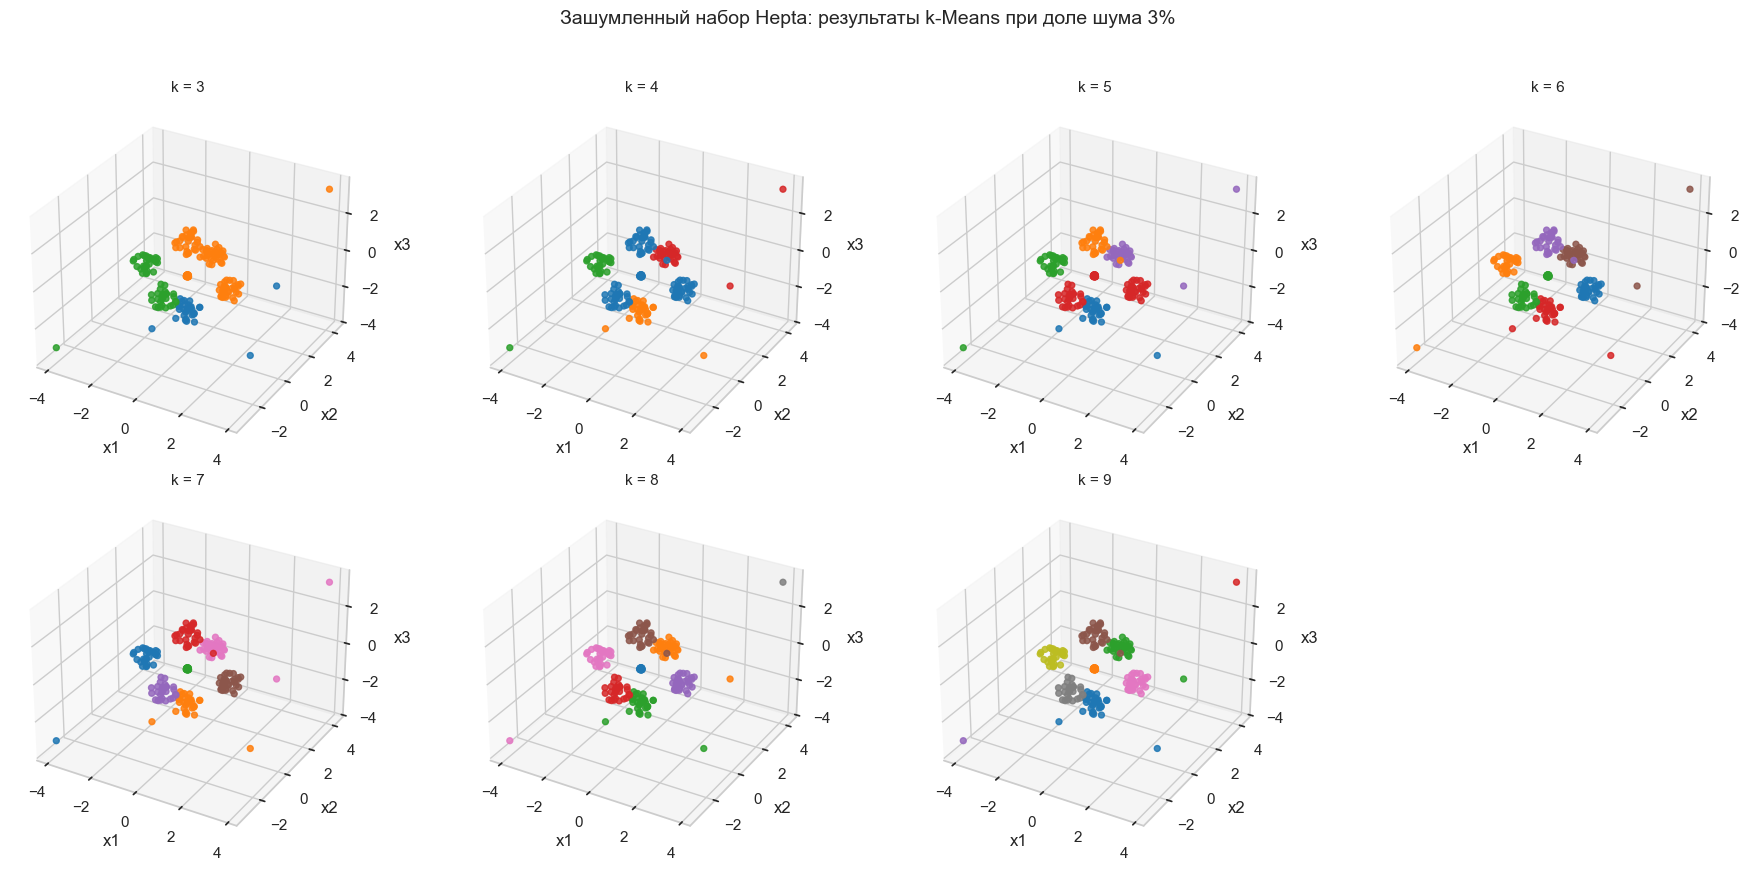

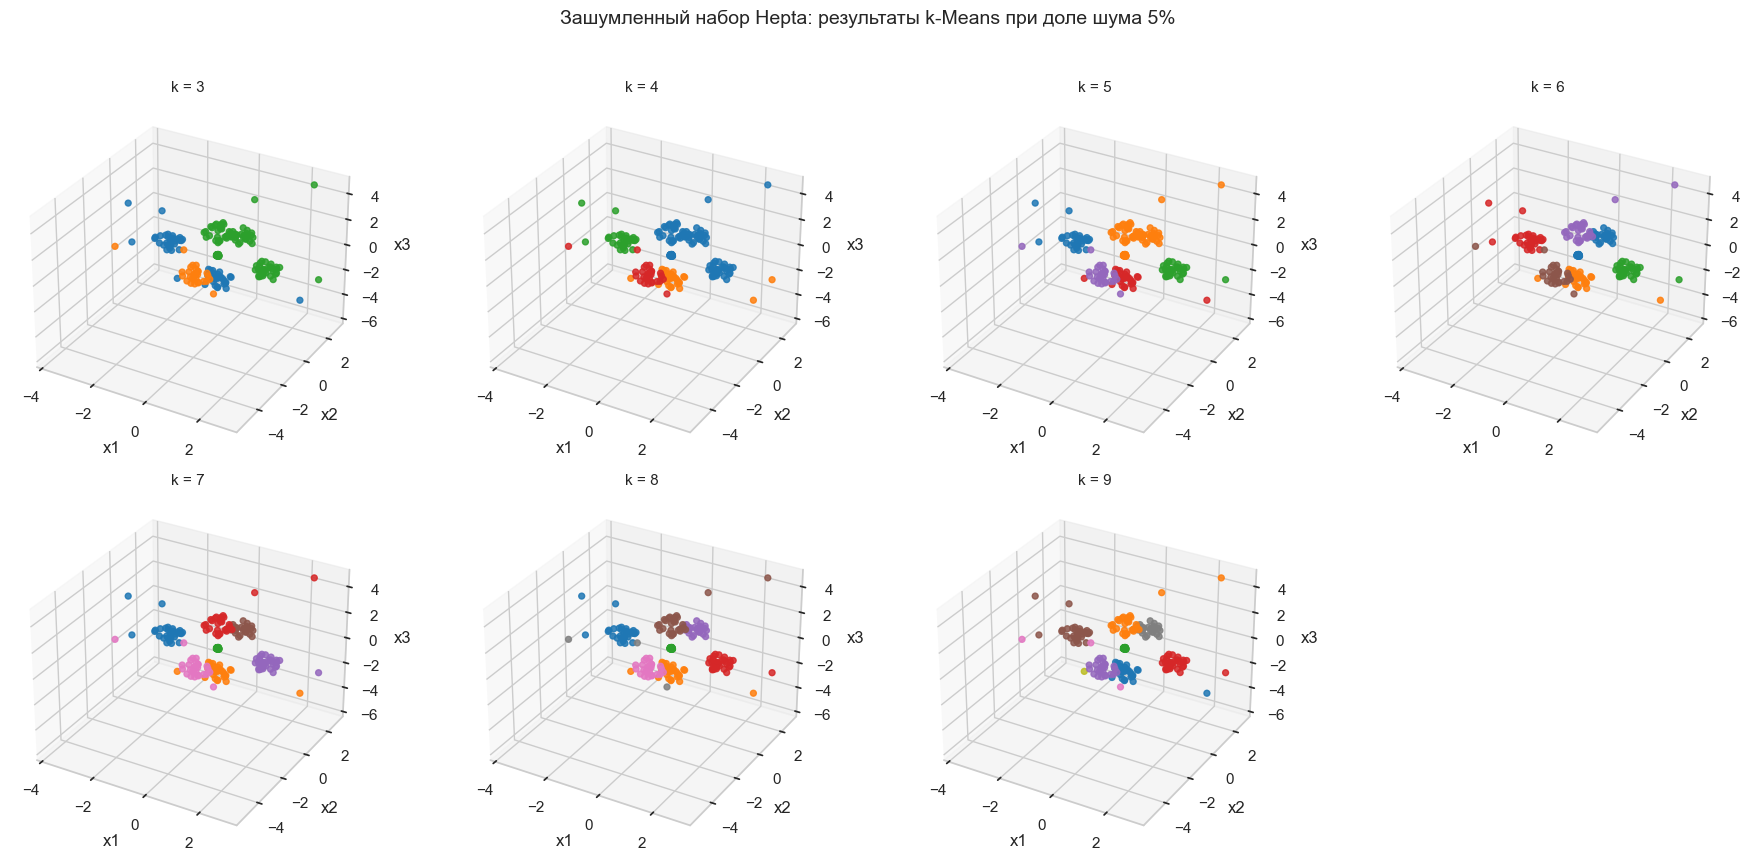

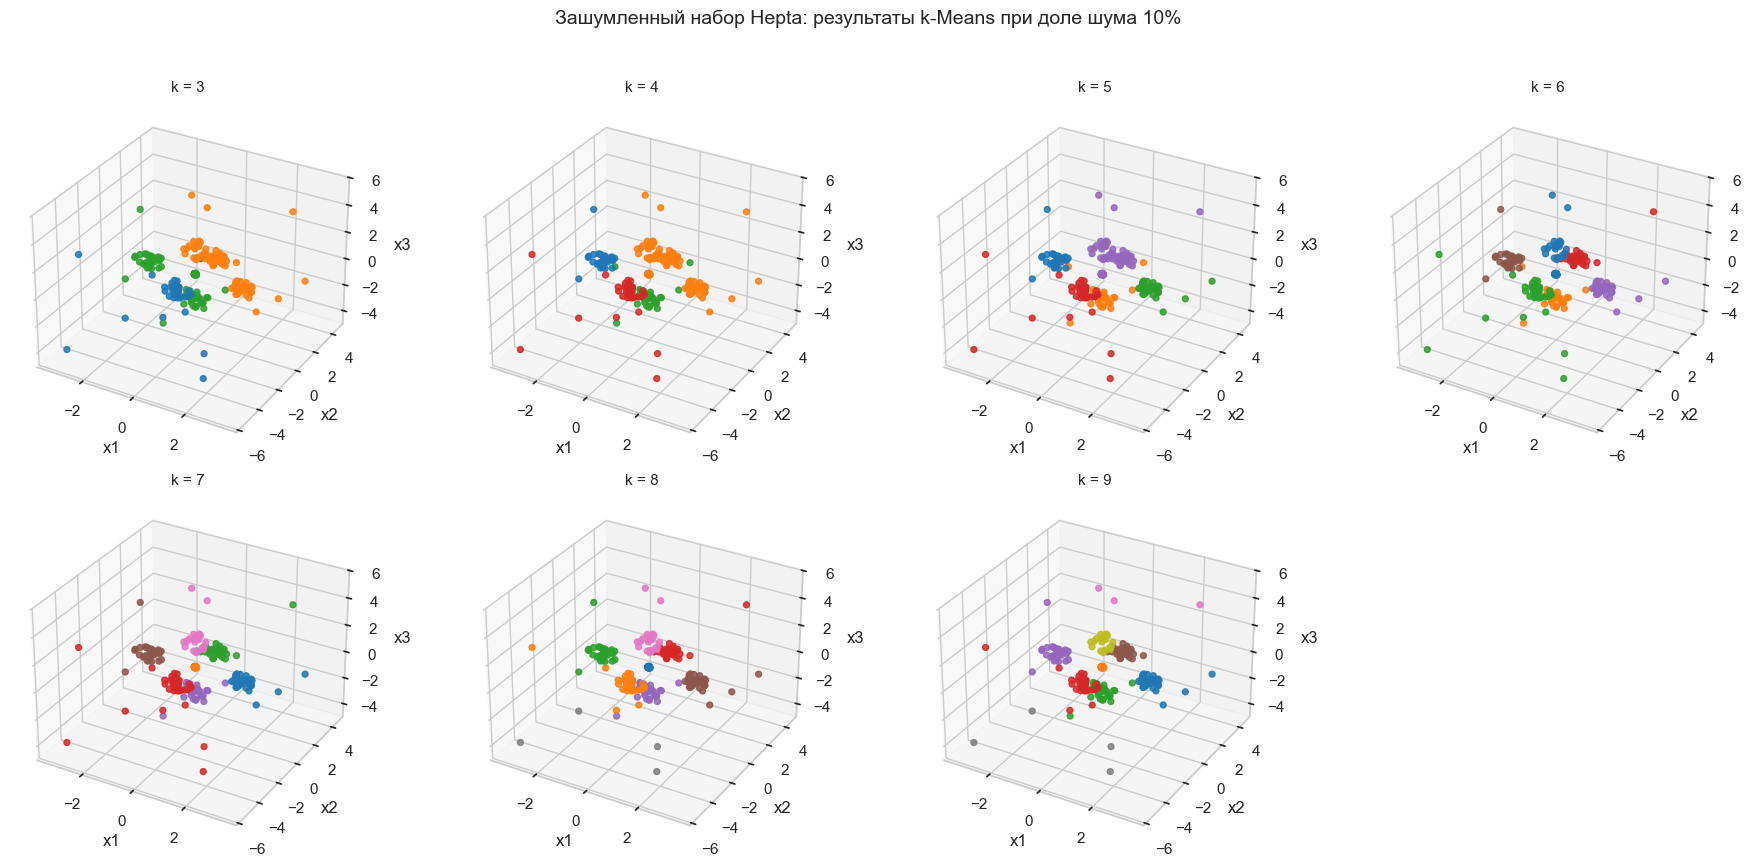

In [25]:
for fraction in NOISE_FRACTIONS:
    plot_cluster_grid(
        data=hepta_noisy_scaled[fraction],
        feature_columns=["x1", "x2", "x3"],
        label_pairs=[(f"k = {row.k}", row.labels) for row in hepta_noisy_kmeans_results[fraction].itertuples()],
        figure_title=f"Зашумленный набор Hepta: результаты k-Means при доле шума {fraction:.0%}",
    )


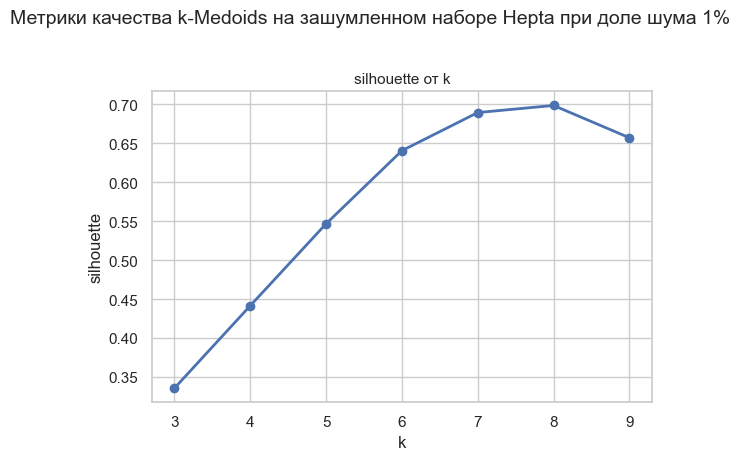

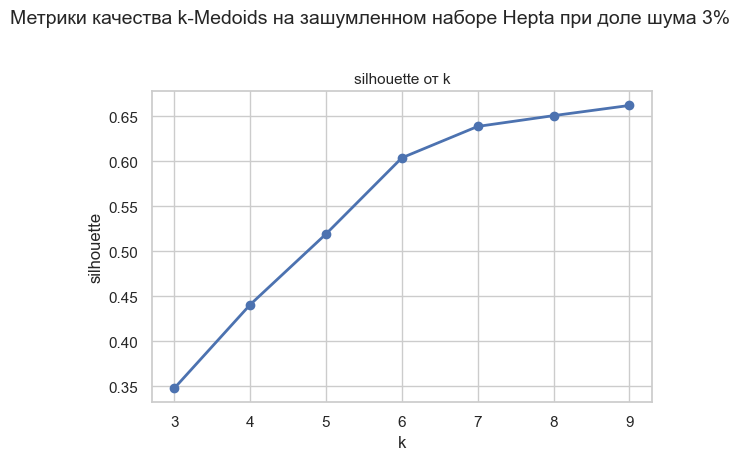

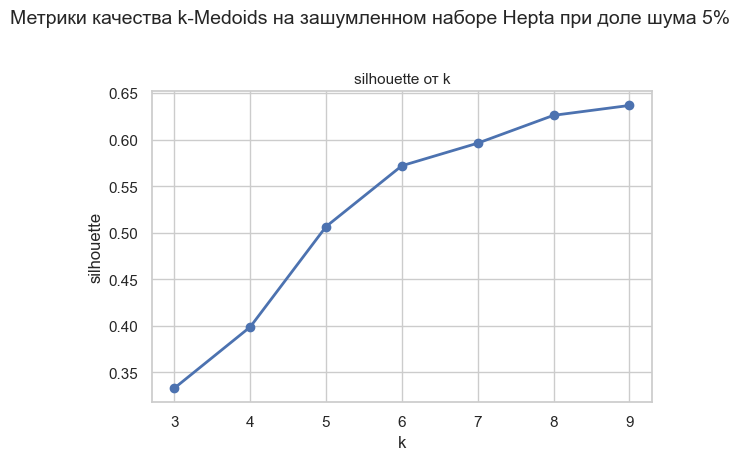

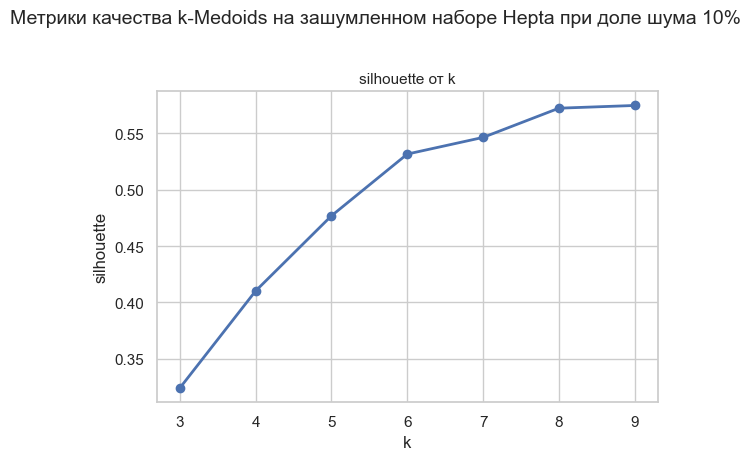

In [26]:
for fraction in NOISE_FRACTIONS:
    plot_metric_curves(
        results=hepta_noisy_kmedoids_results[fraction],
        x_column="k",
        metric_columns=["silhouette"],
        figure_title=f"Метрики качества k-Medoids на зашумленном наборе Hepta при доле шума {fraction:.0%}",
    )


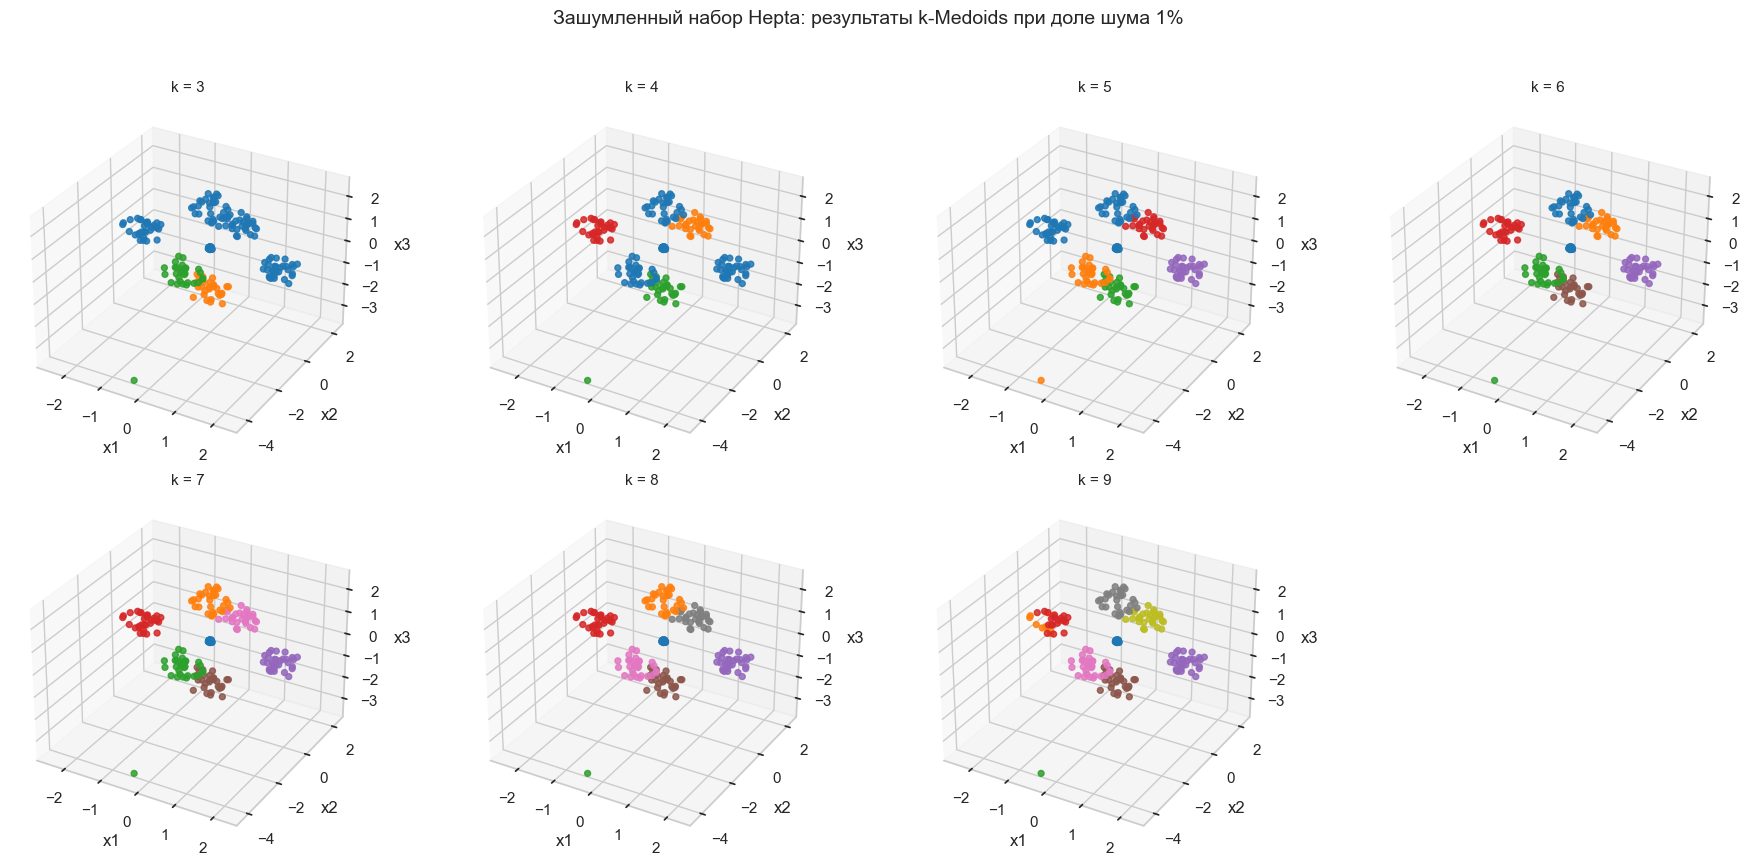

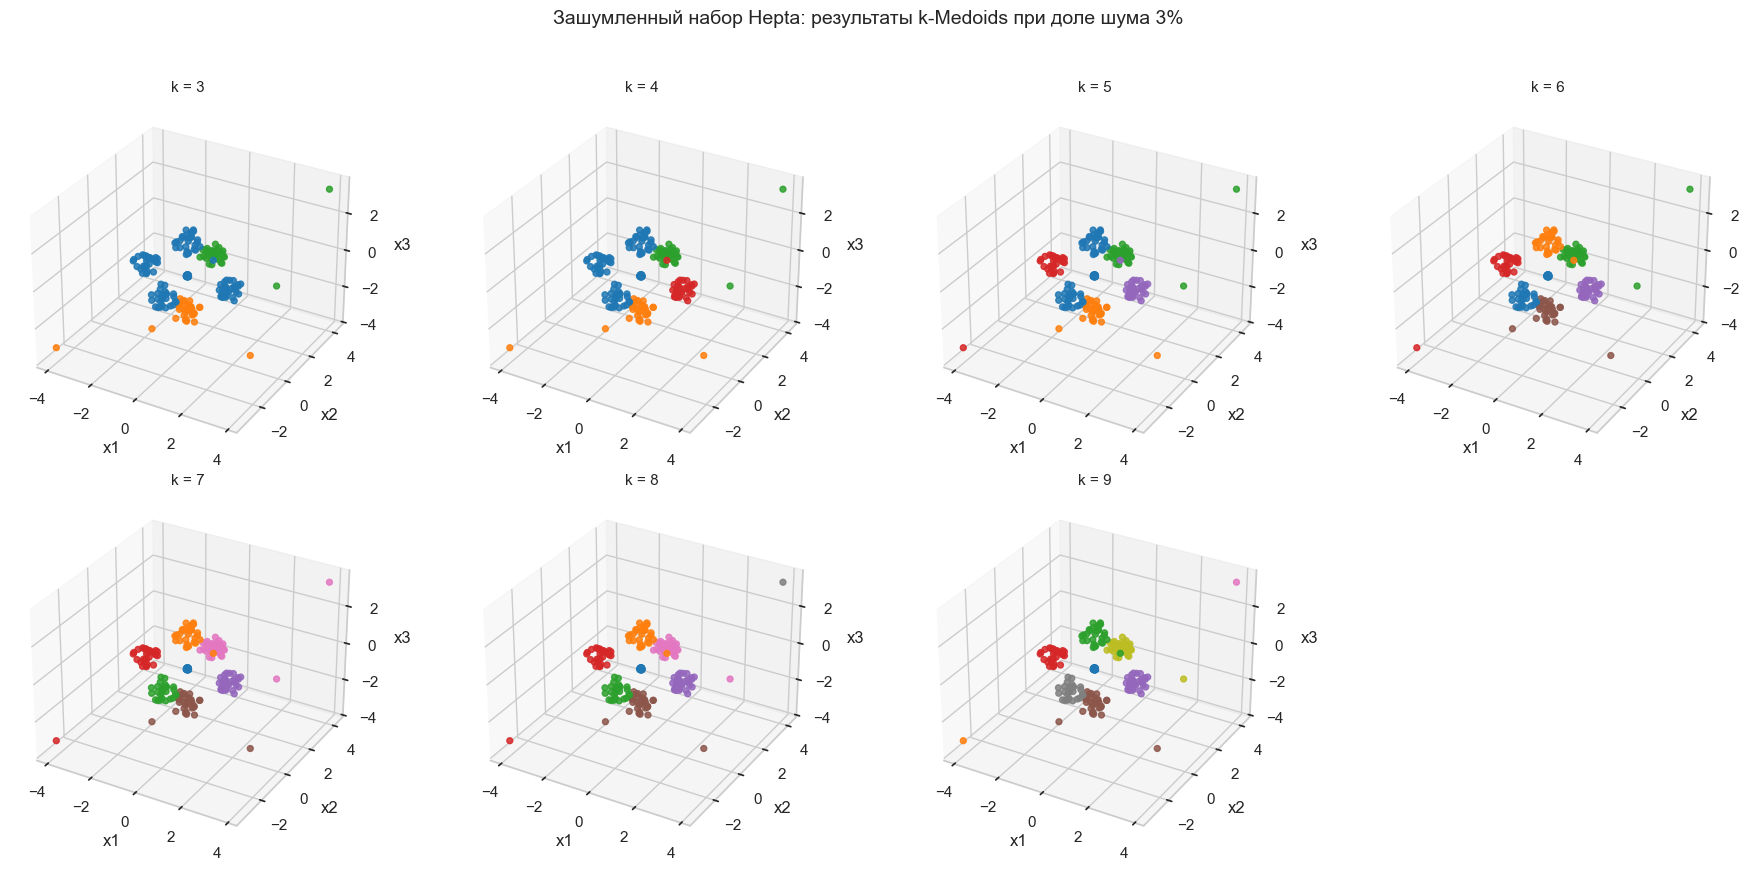

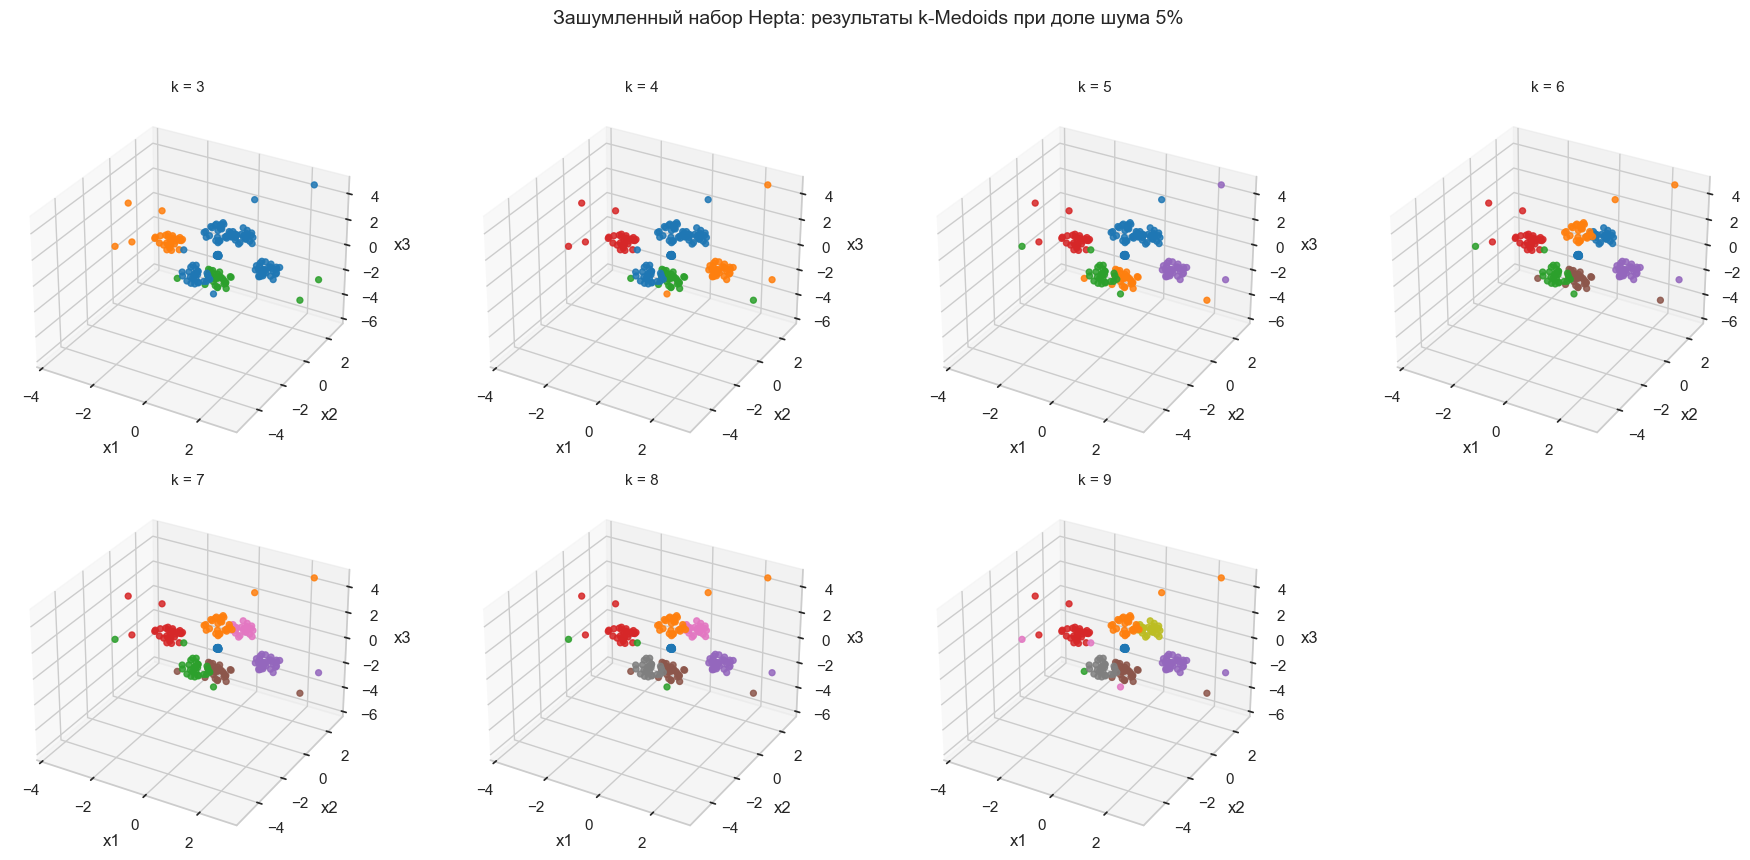

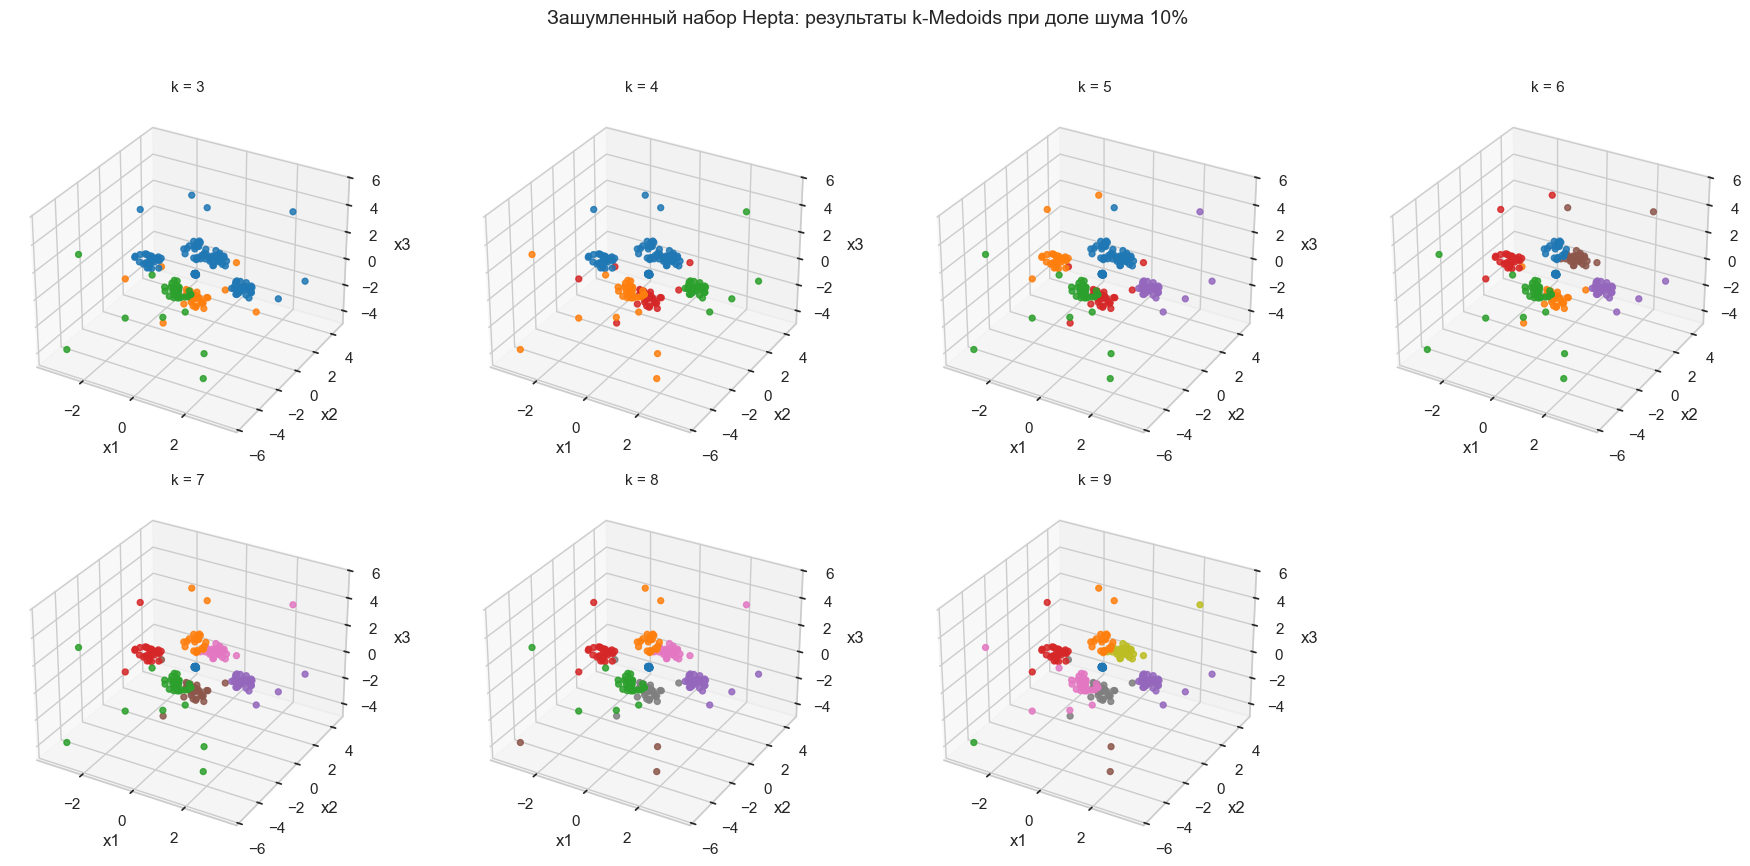

In [27]:
for fraction in NOISE_FRACTIONS:
    plot_cluster_grid(
        data=hepta_noisy_scaled[fraction],
        feature_columns=["x1", "x2", "x3"],
        label_pairs=[(f"k = {row.k}", row.labels) for row in hepta_noisy_kmedoids_results[fraction].itertuples()],
        figure_title=f"Зашумленный набор Hepta: результаты k-Medoids при доле шума {fraction:.0%}",
    )


### 5.3. Разделительная кластеризация невыпуклого набора `Target`


In [28]:
target_kmeans_results = run_kmeans_grid(target_scaled_df, ["x1", "x2"], range(3, 10))
target_kmedoids_results = run_kmedoids_grid(target_scaled_df, ["x1", "x2"], range(3, 10))


In [29]:
target_kmeans_results[["k", "inertia", "silhouette"]]


,k,inertia,silhouette
0,3,781.9749,0.4547
1,4,550.2112,0.5168
2,5,372.7072,0.5690
3,6,300.1621,0.5821
4,7,252.8941,0.5832
5,8,216.8733,0.5873
6,9,194.9514,0.4194


In [30]:
target_kmedoids_results[["k", "silhouette"]]


,k,silhouette
0,3,0.4542
1,4,0.5106
2,5,0.5686
3,6,0.5794
4,7,0.4005
5,8,0.4130
6,9,0.4187


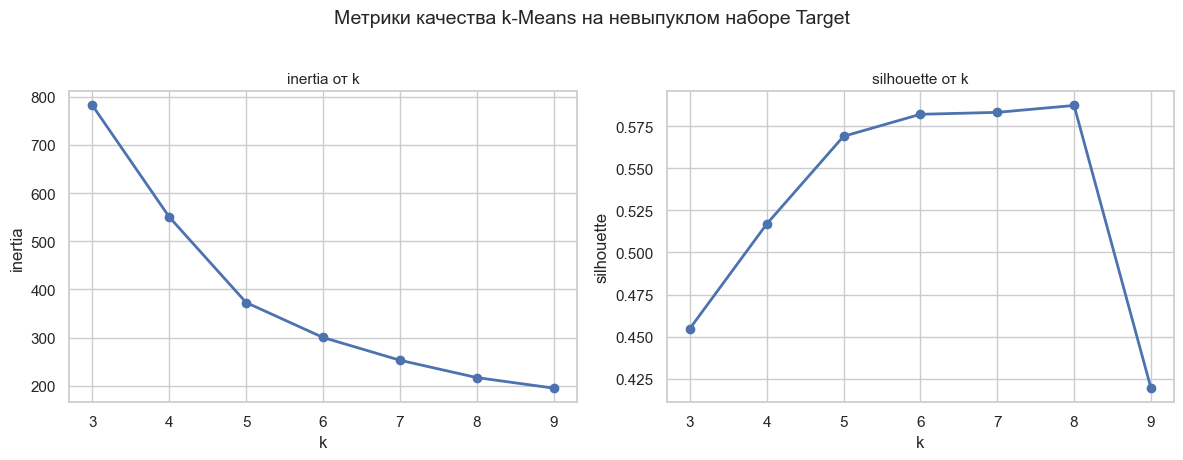

In [32]:
plot_metric_curves(
    results=target_kmeans_results,
    x_column="k",
    metric_columns=["inertia", "silhouette"],
    figure_title="Метрики качества k-Means на невыпуклом наборе Target",
)


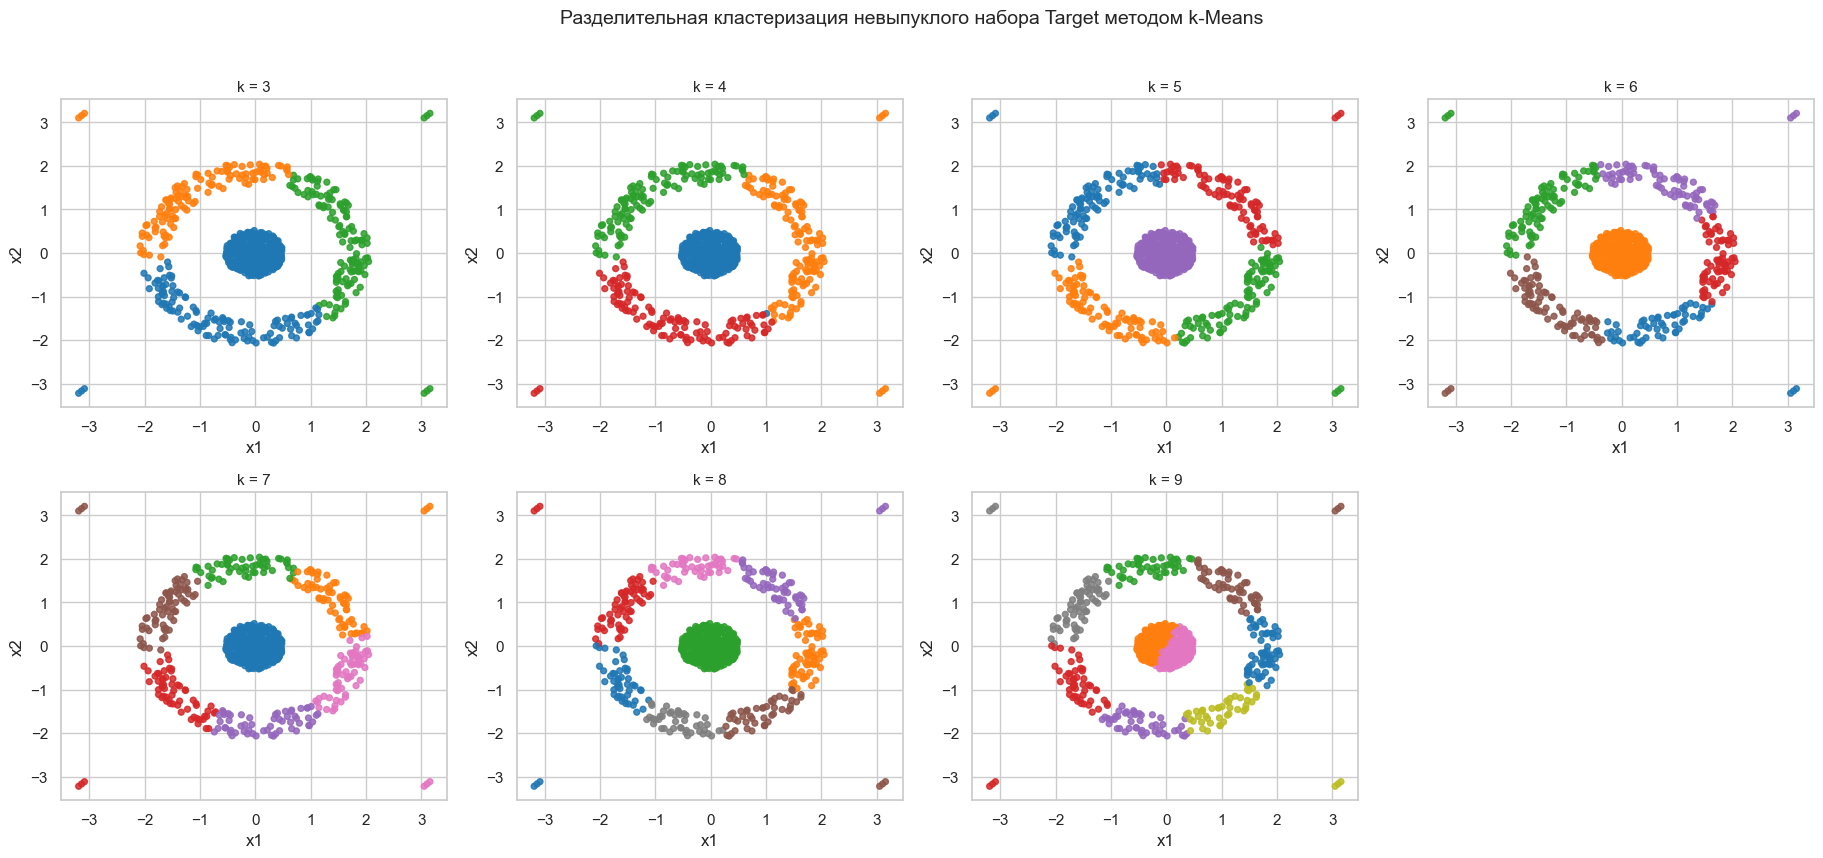

In [31]:
plot_cluster_grid(
    data=target_scaled_df,
    feature_columns=["x1", "x2"],
    label_pairs=[(f"k = {row.k}", row.labels) for row in target_kmeans_results.itertuples()],
    figure_title="Разделительная кластеризация невыпуклого набора Target методом k-Means",
)


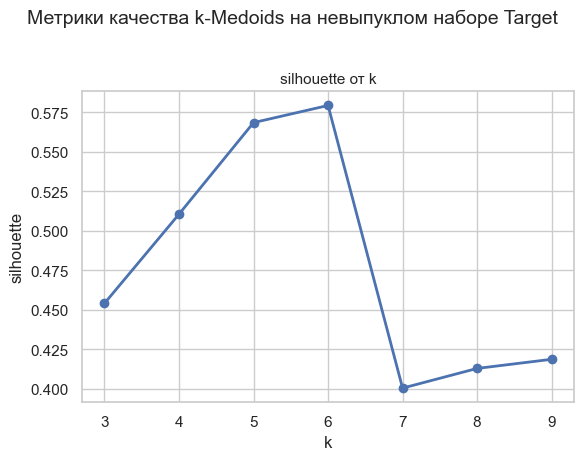

In [34]:
plot_metric_curves(
    results=target_kmedoids_results,
    x_column="k",
    metric_columns=["silhouette"],
    figure_title="Метрики качества k-Medoids на невыпуклом наборе Target",
)


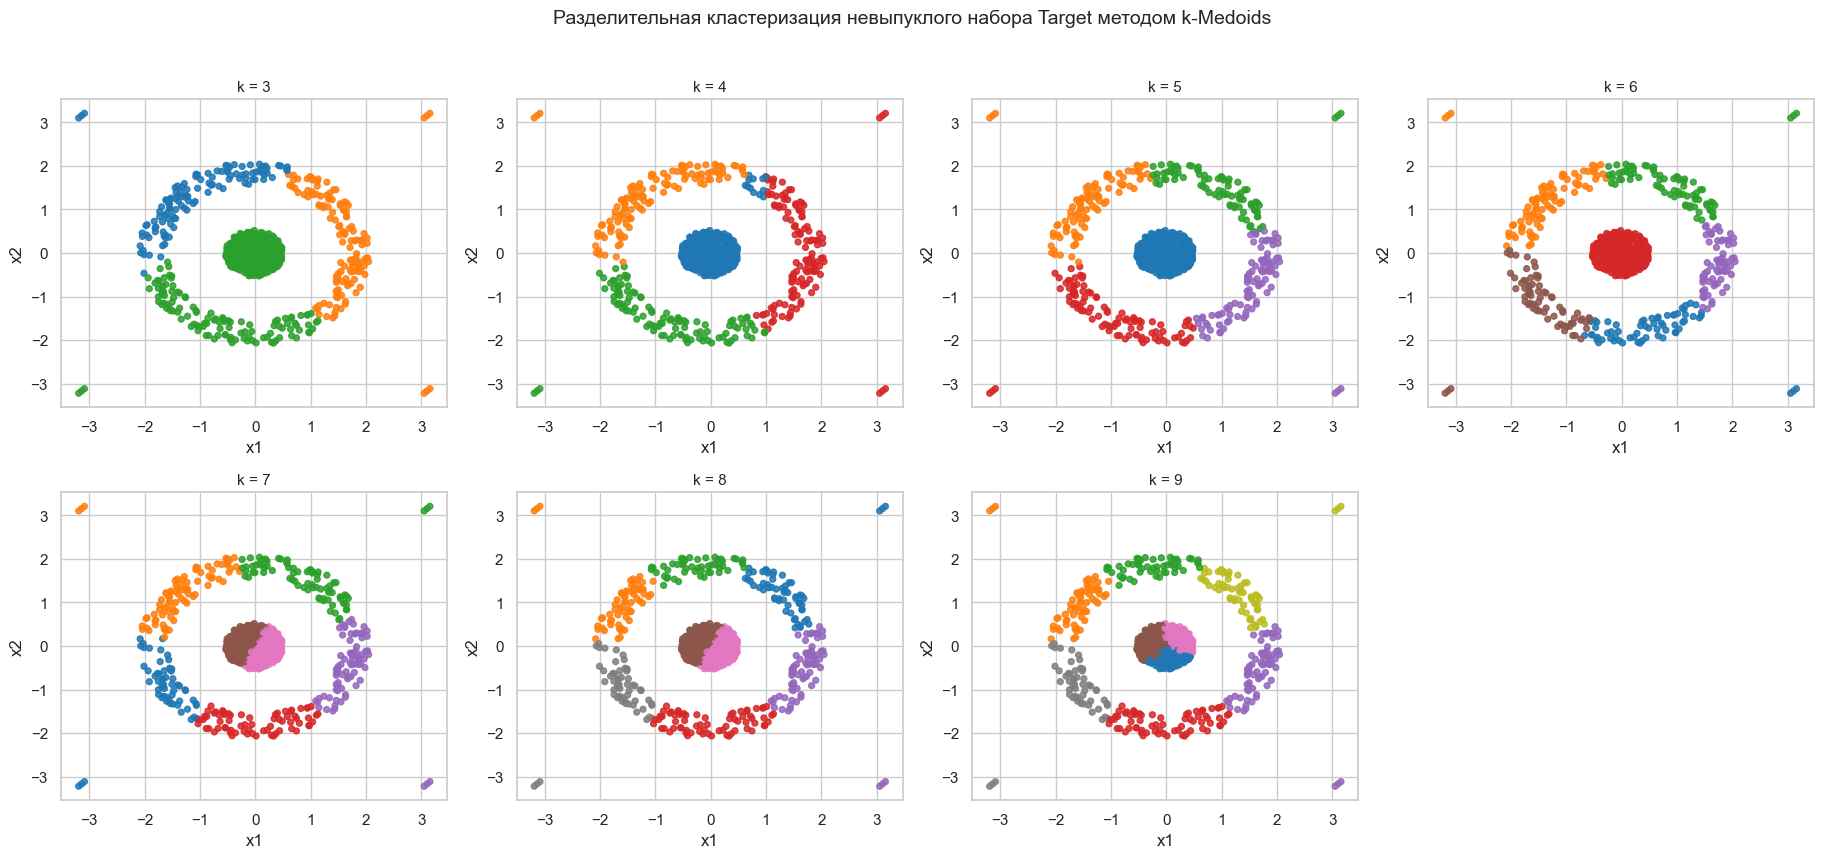

In [33]:
plot_cluster_grid(
    data=target_scaled_df,
    feature_columns=["x1", "x2"],
    label_pairs=[(f"k = {row.k}", row.labels) for row in target_kmedoids_results.itertuples()],
    figure_title="Разделительная кластеризация невыпуклого набора Target методом k-Medoids",
)


## 8. Вывод

Проведенное исследование показывает, что на выпуклом наборе `Hepta` алгоритм `k-Means`
формирует устойчивую интерпретируемую структуру кластеров, тогда как на невыпуклом наборе `Target`
разделительные методы неизбежно дробят естественную форму данных. При увеличении доли и амплитуды шумовых
искажений преимущество `k-Medoids` становится более заметным, поскольку медоиды оказываются менее чувствительными
к выбросам, чем центроиды `k-Means`.
